# <span style="color:red; font-size:30px"> DATASCI 151 — Final Project </span>

<font size="4">

**Group Members:** [Student 1 ID] | [Student 2 ID] | [Student 3 ID] | [Student 4 ID]

## Introduction

<font size="4">

Formula One (F1) is the world’s most renowned class of single-seater auto racing and operates under the rules of the Fédération Internationale de l'Automobile (FIA) ever since its founding in the 1950s. As the summit of motorsport, it combines ground breaking technology with elite driving skill. Each season, teams or “constructors” compete in around 20 races held around the globe. In each of these races, drivers earn championship points based on their finishing position in each race. Among these drivers, whoever has the most points at the end of the season triumphs the Drivers’ Championship. 

The question our team investigates in this project is: “Which countries produce the best Formula One drivers?” We are interested in this question because F1 gathers talent from all over the world and a country’s national background can reflect differences in motorsport culture, infrastructure and access to sport at youth. From the Formula One dataset which covers races from 1950-2024, we used three tables: result.csv, drivers.csv, and races.csv. The driver quality was measured using total career points, number of race wins, win rates (wins per race entered), and average finishing position. Based on our analysis, we found that British and German drivers place top in total points while Finnish and Brazilian drivers stand out when considering the number of drivers each country has produced. We also discovered that F1 has become more internationally diverse over time, especially since the 1990s. The framework for this project will start with describing the dataset and cleaning process, presenting the summary statistics and lastly answering our research question through tables and plots.

## Data Description

<font size="4">
Import the necessary libraries and reading in the three datasets we will use.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_results = pd.read_csv("results.csv")
df_drivers = pd.read_csv("drivers.csv")
df_races = pd.read_csv("races.csv")

<font size="4">

To answer our research question, we need to combine information from multiple datasets so we can look at drivers, their nationalities, and their performance over time in one place.
We use three tables from the Formula One Kaggle dataset given to us(https://www.kaggle.com/datasets/thedevastator/formula-one-racing-a-comprehensive-data-analysis), which covers every F1 race from 1950 through 2024. 
results.csv: One row per driver per race entry. Includes data about each driver's starting grid position, finishing position, and points earned.
drivers.csv: This dataset has one row per driver. Includes each driver's name and nationality, which is a key dataset we need for our research question.
races.csv: One row per race. Includes the year each race took place, gives us data needed to see how the sport has changed over time.

Check the dimensions of each table:

In [ ]:
n_rows_results, n_cols_results = df_results.shape
n_rows_drivers, n_cols_drivers = df_drivers.shape
n_rows_races, n_cols_races = df_races.shape

print("results.csv:", n_rows_results, "rows,", n_cols_results,"columns")
print("drivers.csv:", n_rows_drivers, "rows,", n_cols_drivers,"columns")
print("races.csv: ", n_rows_races, "rows,", n_cols_races, "columns")

results.csv: 25660 rows, 18 columns
drivers.csv: 854 rows, 9 columns
races.csv:   1079 rows, 18 columns


<font size="4">

### Merging

To bring everything together, we merge the datasets step by step using pd.merge.
First, we merge results with drivers using driverId. This adds each driver’s nationality to their race results.Then, we merge that combined dataset with races using raceId, which adds the year of each race.
We use a left join (how="left") throughout because we want to keep all race results, even if some driver or race information might be missing. We also only keep the columns we actually need (like nationality, year, and performance metrics) to keep the dataset clean and easier to work with.

By merging these tables, we create one dataset that lets us directly compare driver performance across countries and over time, which is are the only data that are necessary to answer our research question.

In [ ]:
# First merge: attach driver name and nationality to each race result
df_merged = pd.merge(
    left = df_results[["resultId", "raceId", "driverId", "grid", "positionOrder", "points"]],
    right = df_drivers[["driverId", "forename", "surname", "nationality"]],
    how = "left",
    on = "driverId"
)

# Second merge: attach the calendar year of each race
df_merged = pd.merge(
    left = df_merged,
    right = df_races[["raceId", "year"]],
    how = "left",
    on = "raceId"
)

print("Merged shape:", df_merged.shape)
display(df_merged.head())

Merged shape: (25660, 10)


,resultId,raceId,driverId,grid,positionOrder,points,forename,surname,nationality,year
0,1,18,1,1,1,10.0,Lewis,Hamilton,British,2008
1,2,18,2,5,2,8.0,Nick,Heidfeld,German,2008
2,3,18,3,7,3,6.0,Nico,Rosberg,German,2008
3,4,18,4,11,4,5.0,Fernando,Alonso,Spanish,2008
4,5,18,5,3,5,4.0,Heikki,Kovalainen,Finnish,2008


<font size="4">

### Data Cleaning

Before analyzing the data, we needed to clean it so it's usable. In results.csv, some missing values are stored as "\\N". Since Python doesn’t recognize this as a missing value, we replace all "\\N" entries with np.nan so they can be handled properly in our analysis.

We then create two new columns that help us measure driver performance more directly. One is amount of wins (equals 1 if the driver finished 1st in a race, and 0 otherwise), and another is podium finishes (equals 1 if the driver finished in the top 3, and 0 otherwise)
These variables make it easier to compare drivers and countries based on success, not just raw finishing positions.

In [33]:
# Check which columns contain the "\\N" sentinel before cleaning
print("Columns with \\\\N values before cleaning:")
for col in df_merged.columns:
    count = (df_merged[col] == "\\N").sum()
    if count > 0:
        print(" ", col, "->", count, "occurrences")

Columns with \\N values before cleaning:


In [34]:
# Replace "\\N" with np.nan across the merged dataframe
df_merged = df_merged.replace("\\N", np.nan)

# Add "win" column: 1 if the driver finished 1st, 0 otherwise
df_merged["win"] = (df_merged["positionOrder"] == 1).apply(lambda x: 1 if x else 0)

# Add "podium" column: 1 if the driver finished in the top 3, 0 otherwise
df_merged["podium"] = (df_merged["positionOrder"] <= 3).apply(lambda x: 1 if x else 0)

display(df_merged.head())

,resultId,raceId,driverId,grid,positionOrder,points,forename,surname,nationality,year,win,podium
0,1,18,1,1,1,10.0,Lewis,Hamilton,British,2008,1,1
1,2,18,2,5,2,8.0,Nick,Heidfeld,German,2008,0,1
2,3,18,3,7,3,6.0,Nico,Rosberg,German,2008,0,1
3,4,18,4,11,4,5.0,Fernando,Alonso,Spanish,2008,0,0
4,5,18,5,3,5,4.0,Heikki,Kovalainen,Finnish,2008,0,0


<font size="4">

### Description of Main Columns
The table below summarizes the main variables we used in our analysis. Each row represents one race entry, a driver in a specific race, and the statistics describe all 25,660 entries in the dataset.

grid: The driver’s starting position in a race. A lower number means a better starting spot (e.g., 1 is starting on pole position).
positionOrder: The driver’s finishing position in the race (1 means they won).
points: The number of championship points earned in that race. The scoring system has changed over time, but higher values still means better performance.
win and podium: These are the binary variables we created. Their averages show how often a driver ends up winning or finishing in the top 3. For example, a mean of about 0.05 for win means roughly 5% of all race entries result in a win.
To keep the table easy to read, we round values to two decimal places and didn't include less important rows like counts and quartiles.

In [35]:
key_cols = ["grid", "positionOrder", "points", "win", "podium"]

summary = df_merged[key_cols].describe()

disp_rows = ["mean", "std", "min", "50%", "max"]
display(summary.loc[disp_rows, :].round(2))

,grid,positionOrder,points,win,podium
mean,11.19,12.89,1.85,0.04,0.13
std,7.25,7.72,4.13,0.20,0.33
min,0.00,1.00,0.00,0.00,0.00
50%,11.00,12.00,0.00,0.00,0.00
max,34.00,39.00,50.00,1.00,1.00


## Results

<font size="4">


### Which countries produce the best F1 drivers?

We defined "Best" by 3 levels: 
1. Total wins: which country has the highest total number of F1 race wins? 
2. Total F1 points: which country has the highest total F1 points (top 10 drivers get F1 points)?
3. Average F1 win rate: which country has the highest average win rate?

For each driver we calculate: total points, total races entered, total wins, total podiums, average finishing position, and win rate (wins divided by races entered).Then we aggragrated these to a national level.

We also restrict some of the nationality-level comparison to countries because some of these nationalities have produced only one or two exceptional drivers and might skew averages. The countries we use must have at least 5 drivers in the dataset.

In [ ]:
# Helper function: given a subset of df_merged for one driver, return their career summary
def career_stats(driver_df):
    total_races = len(driver_df)
    total_points = driver_df["points"].sum()
    total_wins = driver_df["win"].sum()
    total_podiums = driver_df["podium"].sum()
    avg_finish = driver_df["positionOrder"].mean()
    win_rate = total_wins / total_races if total_races > 0 else 0
    return [total_races, total_points, total_wins, total_podiums, avg_finish, win_rate]

# Get the list of unique driver IDs
driver_ids = pd.unique(df_merged["driverId"])

# Loop over each driver and collect their career stats
rows_list = []

for driver_id in driver_ids:
    driver_df = df_merged.query("driverId == @driver_id")
    nationality = driver_df["nationality"].iloc[0]
    forename = driver_df["forename"].iloc[0]
    surname = driver_df["surname"].iloc[0]
    stats = career_stats(driver_df)
    rows_list.append([driver_id, forename, surname, nationality] + stats)

# Assemble into a DataFrame
col_names = ["driverId", "forename", "surname", "nationality",
             "total_races", "total_points", "total_wins",
             "total_podiums", "avg_finish", "win_rate"]

df_careers = pd.DataFrame(rows_list, columns=col_names)

print("df_careers shape:", df_careers.shape)
display(df_careers.head())

df_careers shape: (854, 10)


,driverId,forename,surname,nationality,total_races,total_points,total_wins,total_podiums,avg_finish,win_rate
0,1,Lewis,Hamilton,British,301,4308.5,103,188,4.707641,0.342193
1,2,Nick,Heidfeld,German,184,259.0,0,13,10.722826,0.000000
2,3,Nico,Rosberg,German,206,1594.5,23,57,8.252427,0.111650
3,4,Fernando,Alonso,Spanish,349,2021.0,32,98,8.409742,0.091691
4,5,Heikki,Kovalainen,Finnish,112,105.0,1,4,13.285714,0.008929


<font size="4">

Now we aggregate to the nationality level and filter to countries with at least 5 drivers.

In [ ]:
# Aggregate career stats to the nationality level
nat_summary = df_careers.groupby("nationality").agg(
    driver_count = ("driverId", "count"),
    total_points = ("total_points", "sum"),
    total_wins = ("total_wins", "sum"),
    avg_win_rate = ("win_rate", "mean"),
    avg_finish = ("avg_finish", "mean")
).reset_index()

# Keep only nationalities with at least 5 drivers
nat_summary = nat_summary.query("driver_count >= 5")

# Sort by total points descending
nat_summary = nat_summary.sort_values("total_points", ascending=False).reset_index(drop=True)

# Display with clean column names and rounded values
nat_display = nat_summary.rename(columns={
    "nationality": "Nationality",
    "driver_count": "Drivers",
    "total_points": "Total Points",
    "total_wins": "Total Wins",
    "avg_win_rate": "Avg Win Rate",
    "avg_finish": "Avg Finish Pos"
})

display(nat_display.round(3))

,Nationality,Drivers,Total Points,Total Wins,Avg Win Rate,Avg Finish Pos
0,British,165,10325.64,308,0.014,16.064
1,German,50,7925.50,179,0.014,18.068
2,Finnish,9,4375.50,57,0.031,15.865
3,Brazilian,32,3423.00,101,0.017,14.739
4,French,73,3422.33,81,0.007,14.996
5,Australian,17,2810.50,43,0.017,17.923
6,Spanish,15,2783.50,33,0.007,16.853
7,Italian,99,2041.66,43,0.010,18.168
8,Dutch,17,1819.50,28,0.011,17.167
9,Mexican,6,1153.00,5,0.008,13.098


<font size="4">

**Interpretation:** 

British drivers have won the most total career championship points in F1 history, followed by German and Finnish drivers. However, total points are partly influenced by the number of drivers a country has sent to F1. The US ranks high in driver count but much lower in average win rate. We then created 3 plots below to separate these effects.

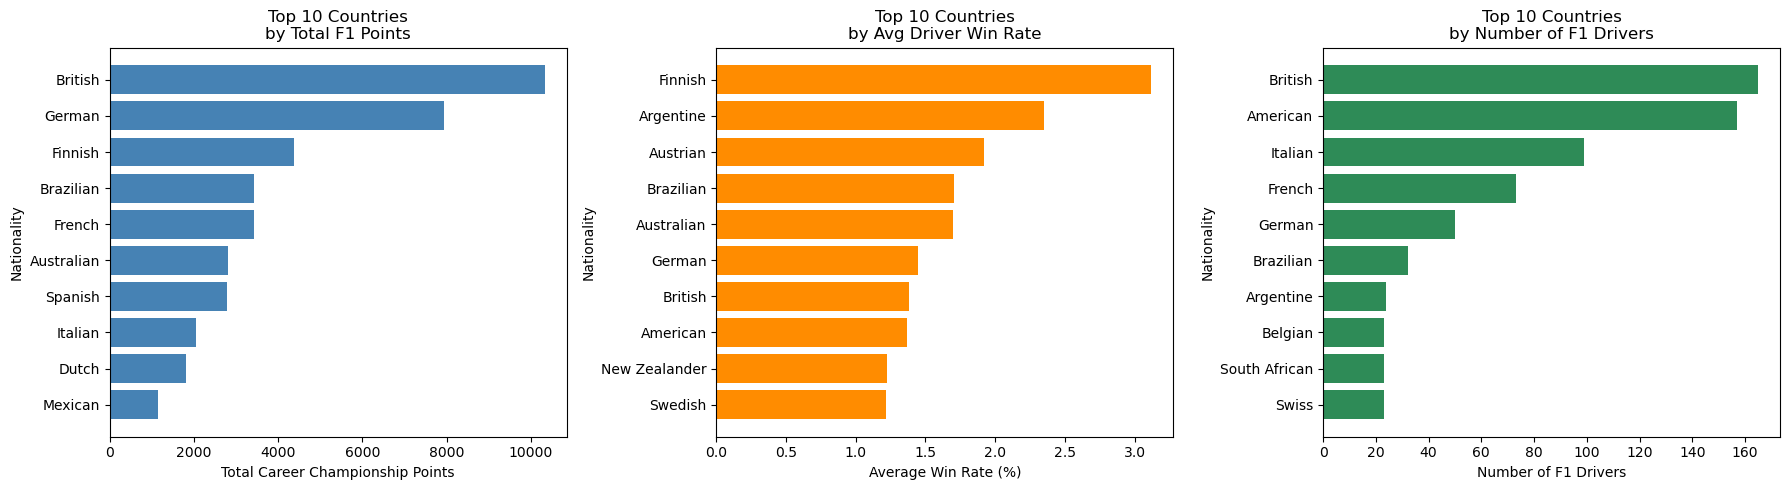

In [ ]:
top10_pts = nat_summary.sort_values("total_points", ascending=False).head(10)
top10_rate = nat_summary.sort_values("avg_win_rate", ascending=False).head(10)
top10_cnt = nat_summary.sort_values("driver_count", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Total Points
axes[0].barh(top10_pts["nationality"][::-1], top10_pts["total_points"][::-1], color="steelblue")
axes[0].set_xlabel("Total Career Championship Points")
axes[0].set_ylabel("Nationality")
axes[0].set_title("Top 10 Countries\nby Total F1 Points")

# Panel 2: Average Win Rate
axes[1].barh(top10_rate["nationality"][::-1], top10_rate["avg_win_rate"][::-1] * 100, color="darkorange")
axes[1].set_xlabel("Average Win Rate (%)")
axes[1].set_ylabel("Nationality")
axes[1].set_title("Top 10 Countries\nby Avg Driver Win Rate")

# Panel 3: Driver Count
axes[2].barh(top10_cnt["nationality"][::-1], top10_cnt["driver_count"][::-1], color="seagreen")
axes[2].set_xlabel("Number of F1 Drivers")
axes[2].set_ylabel("Nationality")
axes[2].set_title("Top 10 Countries\nby Number of F1 Drivers")

plt.tight_layout()
plt.show()

<font size="4">

**Interpretation:** 
The left panel: British and German drivers dominate on total F1 points. British almost has a total career championship points twice the amount of the third country Finland. 

The middle panel (average win rate) tells a different story: Finnish and Brazilian drivers win at a far higher rate per race entered. It's possibly because of legendary careers like Ayrton Senna and Nelson Piquet for Brazil, and Mika Häkkinen and Kimi Räikkönen for Finland. 

The right panel: It explains the reason that UK and US rank so high in raw totals. They have sent the most drivers to F1 by far. The US has a high driver count but a low win rate which suggests a large cohort of non-competitive one-race entrants from the early American Grands Prix.

<font size="4">

Finally, to understand how Formula 1 has become more global, we look at how the diversity of driver nationalities has changed over time. Using the year column from races.csv, we group races into decades and count how many different nationalities appeared on the grid in each decade, allowing us to track whether F1 has become more internationally diverse as the sport has grown.

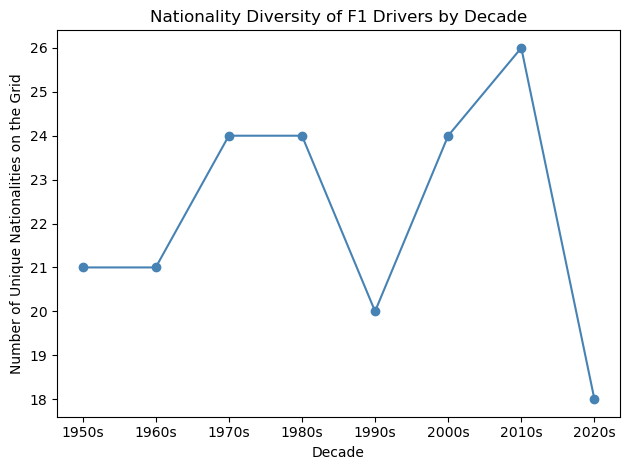

In [ ]:
# Add a decade column using the year from races.csv
df_merged["decade"] = (df_merged["year"] // 10 * 10).apply(lambda x: str(int(x)) + "s")

# Count unique nationalities per decade using a loop
decades = sorted(pd.unique(df_merged["decade"]))
nat_per_decade = []

for decade in decades:
    decade_df = df_merged.query("decade == @decade")
    unique_nat = pd.unique(decade_df["nationality"])
    nat_per_decade.append(len(unique_nat))

plt.figure()
plt.plot(decades, nat_per_decade, marker="o", color="steelblue")
plt.xlabel("Decade")
plt.ylabel("Number of Unique Nationalities on the Grid")
plt.title("Nationality Diversity of F1 Drivers by Decade")
plt.tight_layout()
plt.show()

<font size="4">

**Interpretation**:
From the graph, we can see that the number of nationalities on the F1 grid generally increased from the 1950s through the 1970s, showing early growth in international participation. There is a slight dip around the 1980s–1990s, followed by a steady increase again in the 2000s and 2010s.
This pattern shows that Formula 1 has expanded globally over time. Especially now as the sport reached new regions such as Asia, the Middle East, and Americas, and as the F1 has become more commercialized, its popularity gained globally.

To give a more detailed picture beyond just country totals, we also include a table showing the top 3 drivers from each of the six leading nationalities based on total points.


In [ ]:
# Top 3 drivers for each of the top 6 nationalities by total points
top_nats = nat_summary.sort_values("total_points", ascending=False).head(6)["nationality"].tolist()

print("Top drivers by nationality:\n")

for nat in top_nats:
    subset = df_careers.query("nationality == @nat")
    subset = subset.sort_values("total_points", ascending=False).head(3).copy()
    subset["full_name"] = subset["forename"] + " " + subset["surname"]
    print(f"{nat}")
    display(
        subset[["full_name", "total_races", "total_points", "total_wins", "win_rate"]]
        .rename(columns={
            "full_name":"Driver",
            "total_races":"Races",
            "total_points":"Points",
            "total_wins":"Wins",
            "win_rate": "Win Rate"
        })
        .reset_index(drop=True)
        .round(3)
    )
    print()

Top drivers by nationality:

British


,Driver,Races,Points,Wins,Win Rate
0,Lewis Hamilton,301,4308.5,103,0.342
1,Jenson Button,309,1235.0,15,0.049
2,David Coulthard,247,535.0,13,0.053



German


,Driver,Races,Points,Wins,Win Rate
0,Sebastian Vettel,291,3077.0,53,0.182
1,Nico Rosberg,206,1594.5,23,0.112
2,Michael Schumacher,308,1566.0,91,0.295



Finnish


...

,Driver,Races,Points,Wins,Win Rate
0,Felipe Massa,271,1167.0,11,0.041
1,Rubens Barrichello,326,658.0,11,0.034
2,Ayrton Senna,162,614.0,41,0.253



French


,Driver,Races,Points,Wins,Win Rate
0,Alain Prost,202,798.5,51,0.252
1,Romain Grosjean,181,391.0,0,0.000
2,Esteban Ocon,102,327.0,1,0.010



Australian


,Driver,Races,Points,Wins,Win Rate
0,Daniel Ricciardo,223,1289.0,8,0.036
1,Mark Webber,217,1047.5,9,0.041
2,Jack Brabham,129,261.0,14,0.109


## Discussion

<font size="4">

Our analysis of Formula One data from 1950 to 2024 shows that the answer to out research question “which countries produce the best drivers”, but it depends on how we define "best".

If we look at total career points, British drivers rank highest, largely due to dominant figures like Lewis Hamilton (7-time world champion), Nigel Mansell, and Damon Hill. Germany follows closely, mainly driven by Michael Schumacher’s success (also a 7-time world champion). However, when we adjust for the number of drivers each country has produced and focus on average performance, countries like Finland and Brazil stand out. Although they have fewer drivers overall, those drivers tend to perform at a very high level.

One key takeaway is that producing a large number of drivers does not necessarily mean producing the best ones. For example, the United States has historically had many drivers in F1, but their average success rate is relatively low. This reflects the fact that many early American entries were less competitive.

We also find that F1 has become more internationally diverse over time, especially since the 1990s, as the sport expanded globally. Overall, countries that consistently produce top drivers, such as the UK, Germany, Finland, and Brazil, tend to have strong motorsport cultures and development systems that help drivers succeed at the highest level.
Looking ahead, our results suggest that Formula 1 will continue to become more globally diverse, with more drivers emerging from a wider range of countries. In today’s F1, we already see this shift, with top drivers like Max Verstappen from the Netherlands and rising young talent such as Kimi Antonelli from Italy making a strong impact on the sport. This, again, shows the idea that as F1 expands globally, the pool of competitive drivers will continue to grow both in size and diversity.